# Sport Recife 2026 — Diagnóstico por Fase (Painel Consolidado)

Integra os três módulos de análise:
- **Módulo 1**: evolução do xG ao longo do tempo
- **Módulo 2**: rotação de elenco e formações  
- **Módulo 3**: força dos adversários

Hipótese central: a deterioração do xG na Fase 2 é explicada pela combinação de rotação massiva de elenco e escalada no nível dos adversários.

In [1]:
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

RESULTS_PATH  = Path('../data/processed/2026/sport/sport_2026_results.csv')
STATS_PATH    = Path('../data/processed/2026/sport/sport_2026_team_match_stats.csv')
PLAYERS_PATH  = Path('../data/processed/2026/players/sport_2026_player_match_stats.csv')
OPP_STR_PATH  = Path('../data/processed/2026/sport/sport_2026_opponent_strength.csv')
OUTPUT_DIR    = Path('../data/processed/2026/sport')

TEAM_NAME        = 'Sport Recife'
FASE1_N_JOGOS    = 3
SERIE_B_DEBUT_TS = pd.Timestamp('2026-03-21T23:30:00', tz='UTC')

FASE_LABELS = {1: 'Fase 1 — Sub20', 2: 'Fase 2 — Pré-Série B', 3: 'Fase 3 — Márcio Goiano'}
FASE_COLORS = {1: '#D97706', 2: '#0369A1', 3: '#047857'}
FASE_BG     = {1: '#FDE68A', 2: '#BAE6FD', 3: '#BBF7D0'}

In [2]:
# ── Carrega e integra todos os dados ─────────────────────────────────────────
results = pd.read_csv(RESULTS_PATH)
results['match_date_utc'] = pd.to_datetime(results['match_date_utc'], utc=True)
results = results.sort_values('match_date_utc').reset_index(drop=True)
results['jogo_num'] = range(1, len(results) + 1)

def assign_phase(row):
    if row['jogo_num'] <= FASE1_N_JOGOS: return 1
    elif row['match_date_utc'] <= SERIE_B_DEBUT_TS: return 2
    else: return 3

results['fase'] = results.apply(assign_phase, axis=1)
results['opponent'] = results.apply(
    lambda r: r['away_team'] if r['home_team'] == TEAM_NAME else r['home_team'], axis=1
)
results['label'] = results['jogo_num'].astype(str) + '. ' + results['opponent'].str.split().str[0]

# xG
team_stats = pd.read_csv(STATS_PATH)
sport_xg = (
    team_stats.loc[team_stats['team_name'].eq(TEAM_NAME)]
    .drop_duplicates('source_url')
    [['source_url','expected_goals','possession','shots_total']]
    .rename(columns={'expected_goals': 'xg_for'})
)
opp_xg = (
    team_stats.loc[~team_stats['team_name'].eq(TEAM_NAME)]
    .drop_duplicates('source_url')
    [['source_url','expected_goals']].rename(columns={'expected_goals': 'xg_against'})
)
results = results.merge(sport_xg, on='source_url', how='left')
results = results.merge(opp_xg,   on='source_url', how='left')
results['xg_diff'] = results['xg_for'] - results['xg_against']

# Força adversários
opp_str = pd.read_csv(OPP_STR_PATH)
mv = opp_str['squad_market_value_eur']
opp_str['market_value_score'] = (mv - mv.min()) / (mv.max() - mv.min())
ppg = opp_str['perf_points_per_game'].fillna(0)
opp_str['perf_score'] = ppg / (ppg.max() if ppg.max() > 0 else 1)
opp_str['strength_score'] = opp_str.apply(
    lambda r: 0.60 * r['market_value_score'] + 0.40 * r['perf_score']
    if pd.notna(r['market_value_score']) else r['perf_score'], axis=1
)
results = results.merge(
    opp_str[['opponent_name','squad_market_value_eur','perf_points_per_game',
             'strength_score','perf_win_rate']],
    left_on='opponent', right_on='opponent_name', how='left'
)

# Rotação e formação
players_raw = pd.read_csv(PLAYERS_PATH)
sport_pl = players_raw.loc[players_raw['team_name'].eq(TEAM_NAME)].copy()
game_meta = results[['match_id','home_team','away_team','competition_name','jogo_num']].copy()
sport_pl = sport_pl.merge(
    game_meta,
    left_on=['match_code','home_team','away_team','competition'],
    right_on=['match_id','home_team','away_team','competition_name'],
    how='left'
)
starters = sport_pl.loc[~sport_pl['is_substitute'] & sport_pl['jogo_num'].notna()]

def formation_string(group):
    pos = group['position'].value_counts()
    return f"{pos.get('D',0)}-{pos.get('M',0)}-{pos.get('F',0)}"

formations  = starters.groupby('jogo_num').apply(formation_string).reset_index(name='formation')
avg_rating  = starters.groupby('jogo_num')['rating'].mean().reset_index(name='avg_rating')
game_starters = (starters.groupby('jogo_num')['player_name']
    .apply(set).reset_index(name='starters_set').sort_values('jogo_num'))
rotations = [
    {'jogo_num': game_starters.iloc[i]['jogo_num'],
     'changes_vs_prev': len(game_starters.iloc[i]['starters_set'] - game_starters.iloc[i-1]['starters_set'])}
    for i in range(1, len(game_starters))
]
rotation_df = pd.DataFrame(rotations)

results = results.merge(formations,  on='jogo_num', how='left')
results = results.merge(avg_rating,  on='jogo_num', how='left')
results = results.merge(rotation_df, on='jogo_num', how='left')

print(f'{len(results)} jogos integrados | {results["xg_for"].notna().sum()} com xG')

19 jogos integrados | 16 com xG


C:\Users\compesa\AppData\Local\Temp\ipykernel_22872\3138365524.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  formations  = starters.groupby('jogo_num').apply(formation_string).reset_index(name='formation')


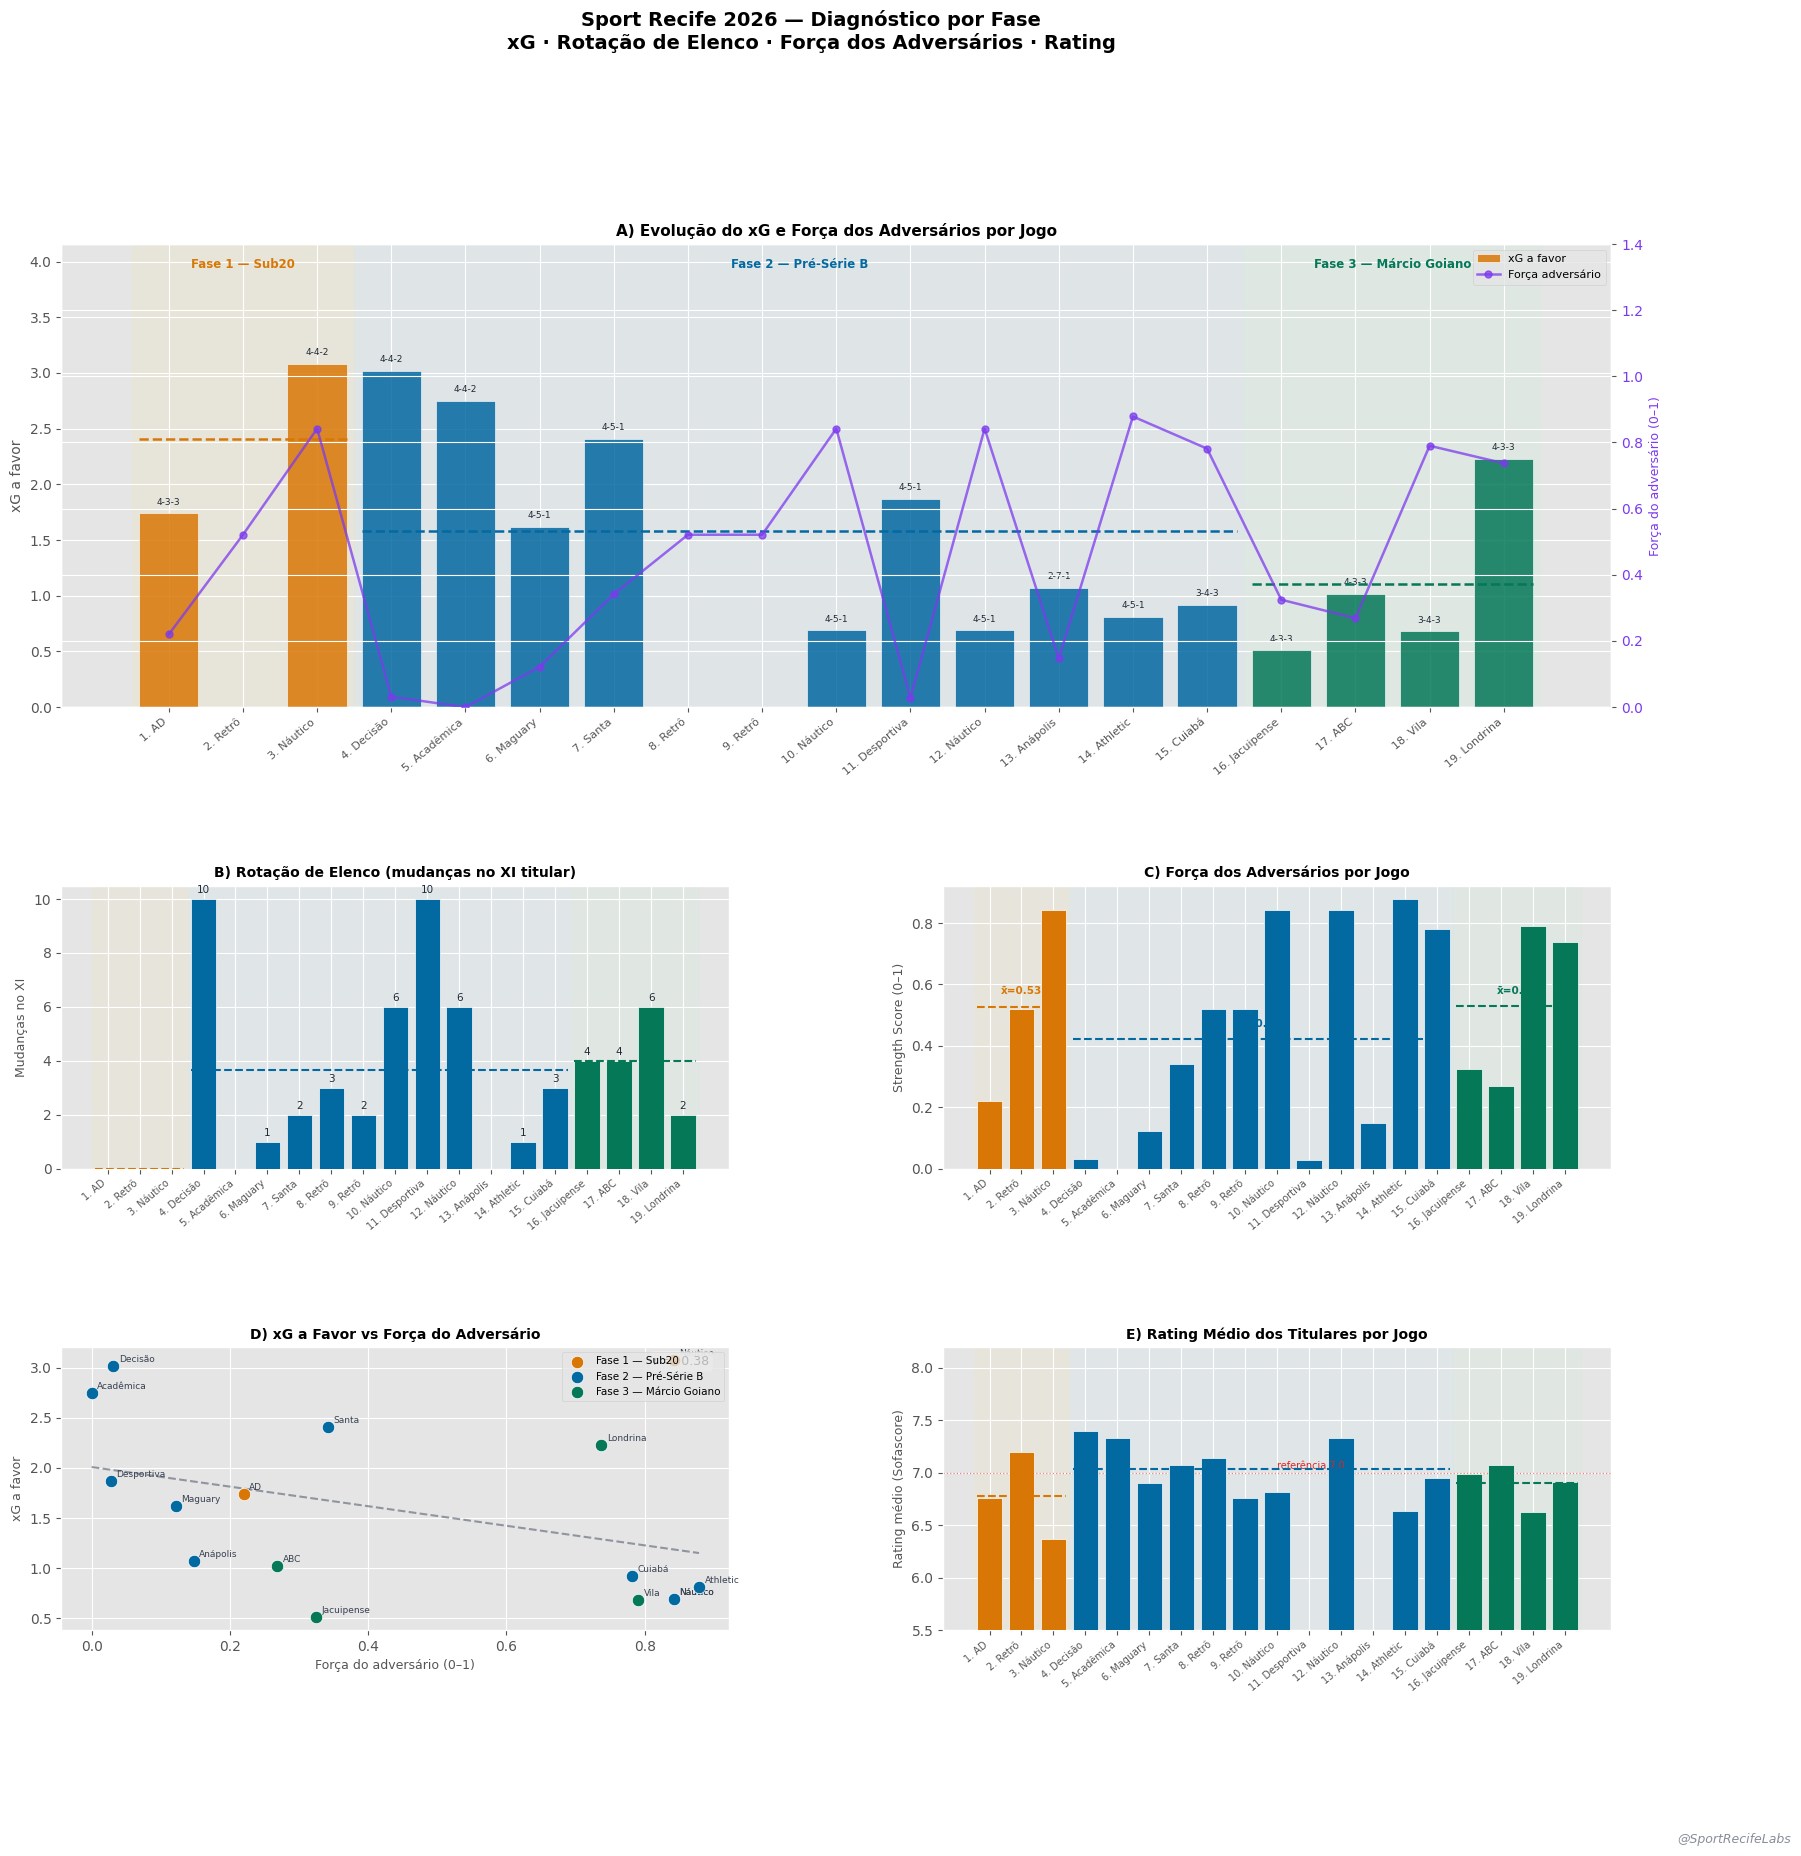

Salvo em ..\data\processed\2026\sport\sport_2026_diagnostico_fases.png


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# PAINEL CONSOLIDADO — 5 subplots
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.32,
                         height_ratios=[1.8, 1.1, 1.1])

ax_xg   = fig.add_subplot(gs[0, :])
ax_rot  = fig.add_subplot(gs[1, 0])
ax_str  = fig.add_subplot(gs[1, 1])
ax_scat = fig.add_subplot(gs[2, 0])
ax_rat  = fig.add_subplot(gs[2, 1])

df = results.copy()
x  = df['jogo_num'].values

def phase_spans(ax, alpha=0.10):
    for fid in sorted(df['fase'].unique()):
        g = df.loc[df['fase'] == fid, 'jogo_num']
        ax.axvspan(g.min() - 0.5, g.max() + 0.5, color=FASE_BG[fid], alpha=alpha, zorder=0)

def phase_means(ax, col, lw=1.8):
    for fid in sorted(df['fase'].unique()):
        sub = df.loc[df['fase'] == fid, col].dropna()
        g   = df.loc[df['fase'] == fid, 'jogo_num'].values
        if sub.empty: continue
        ax.hlines(sub.mean(), g.min() - 0.4, g.max() + 0.4,
                  color=FASE_COLORS[fid], linewidth=lw, linestyle='--', zorder=4)

bar_colors = [FASE_COLORS[r['fase']] for _, r in df.iterrows()]

# ── A) xG evolution + força no eixo secundário ───────────────────────────────
ax_xg.bar(x, df['xg_for'].fillna(0), color=bar_colors, alpha=0.85,
           edgecolor='white', linewidth=0.5, zorder=3, label='xG a favor')
for _, row in df.iterrows():
    if pd.notna(row.get('formation')) and pd.notna(row.get('xg_for')):
        ax_xg.text(row['jogo_num'], row['xg_for'] + 0.06, row['formation'],
                   ha='center', va='bottom', fontsize=6.5, color='#1F2937')

ax_xg2 = ax_xg.twinx()
ax_xg2.plot(x, df['strength_score'], color='#7C3AED', linewidth=1.8,
             marker='o', markersize=5, alpha=0.75, zorder=5, label='Força adversário')
ax_xg2.set_ylabel('Força do adversário (0–1)', fontsize=9, color='#7C3AED')
ax_xg2.tick_params(axis='y', labelcolor='#7C3AED')
ax_xg2.set_ylim(0, 1.4)

phase_spans(ax_xg, alpha=0.12)
phase_means(ax_xg, 'xg_for')
ax_xg.set_xticks(x)
ax_xg.set_xticklabels(df['label'], rotation=40, ha='right', fontsize=8)
ax_xg.set_ylabel('xG a favor', fontsize=10)
ax_xg.set_ylim(0, df['xg_for'].max() * 1.35)
ax_xg.set_title('A) Evolução do xG e Força dos Adversários por Jogo',
                fontsize=11, fontweight='bold')
for fid in sorted(df['fase'].unique()):
    g = df.loc[df['fase'] == fid, 'jogo_num']
    ax_xg.text(g.mean(), df['xg_for'].max() * 1.28, FASE_LABELS[fid],
               ha='center', fontsize=8.5, fontweight='bold', color=FASE_COLORS[fid])

lines1, labels1 = ax_xg.get_legend_handles_labels()
lines2, labels2 = ax_xg2.get_legend_handles_labels()
ax_xg.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

# ── B) Rotação ────────────────────────────────────────────────────────────────
ax_rot.bar(x, df['changes_vs_prev'].fillna(0), color=bar_colors,
            edgecolor='white', linewidth=0.5, zorder=3)
for _, row in df.iterrows():
    val = row.get('changes_vs_prev')
    if pd.notna(val) and val > 0:
        ax_rot.text(row['jogo_num'], val + 0.15, str(int(val)),
                    ha='center', va='bottom', fontsize=7.5, color='#1F2937')
phase_spans(ax_rot)
phase_means(ax_rot, 'changes_vs_prev', lw=1.5)
ax_rot.set_xticks(x)
ax_rot.set_xticklabels(df['label'], rotation=40, ha='right', fontsize=7)
ax_rot.set_ylabel('Mudanças no XI', fontsize=9)
ax_rot.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_rot.set_title('B) Rotação de Elenco (mudanças no XI titular)', fontsize=10, fontweight='bold')

# ── C) Força adversários ──────────────────────────────────────────────────────
ax_str.bar(x, df['strength_score'].fillna(0), color=bar_colors,
            edgecolor='white', linewidth=0.5, zorder=3)
phase_spans(ax_str)
phase_means(ax_str, 'strength_score', lw=1.5)
for fid in sorted(df['fase'].unique()):
    sub = df.loc[df['fase'] == fid, 'strength_score'].dropna()
    g   = df.loc[df['fase'] == fid, 'jogo_num']
    if not sub.empty:
        ax_str.text(g.mean(), sub.mean() + 0.04, f'x\u0304={sub.mean():.2f}',
                    ha='center', fontsize=7.5, color=FASE_COLORS[fid], fontweight='bold')
ax_str.set_xticks(x)
ax_str.set_xticklabels(df['label'], rotation=40, ha='right', fontsize=7)
ax_str.set_ylabel('Strength Score (0–1)', fontsize=9)
ax_str.set_title('C) Força dos Adversários por Jogo', fontsize=10, fontweight='bold')

# ── D) Scatter xG vs força ────────────────────────────────────────────────────
scat_df = df.dropna(subset=['xg_for','strength_score'])
for fid in sorted(scat_df['fase'].unique()):
    fsub = scat_df.loc[scat_df['fase'] == fid]
    ax_scat.scatter(fsub['strength_score'], fsub['xg_for'],
                    color=FASE_COLORS[fid], s=80, zorder=5,
                    edgecolors='white', linewidths=0.5, label=FASE_LABELS[fid])
    for _, row in fsub.iterrows():
        ax_scat.annotate(row['label'].split('. ')[1],
                         xy=(row['strength_score'], row['xg_for']),
                         xytext=(4, 3), textcoords='offset points',
                         fontsize=6.5, color='#374151')

x_reg = scat_df['strength_score'].values
y_reg = scat_df['xg_for'].values
coef  = np.polyfit(x_reg, y_reg, 1)
x_line = np.linspace(x_reg.min(), x_reg.max(), 100)
ax_scat.plot(x_line, np.polyval(coef, x_line), color='#6B7280',
              linewidth=1.5, linestyle='--', alpha=0.7)
r = np.corrcoef(x_reg, y_reg)[0, 1]
ax_scat.text(0.97, 0.97, f'r = {r:.2f}', transform=ax_scat.transAxes,
              ha='right', va='top', fontsize=9,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax_scat.set_xlabel('Força do adversário (0–1)', fontsize=9)
ax_scat.set_ylabel('xG a favor', fontsize=9)
ax_scat.set_title('D) xG a Favor vs Força do Adversário', fontsize=10, fontweight='bold')
ax_scat.legend(fontsize=7.5, loc='upper right')

# ── E) Rating médio ───────────────────────────────────────────────────────────
ax_rat.bar(x, df['avg_rating'].fillna(0), color=bar_colors,
            edgecolor='white', linewidth=0.5, zorder=3)
phase_spans(ax_rat)
phase_means(ax_rat, 'avg_rating', lw=1.5)
ax_rat.axhline(7.0, color='#DC2626', linewidth=0.9, linestyle=':', alpha=0.6)
ax_rat.set_xticks(x)
ax_rat.set_xticklabels(df['label'], rotation=40, ha='right', fontsize=7)
ax_rat.set_ylabel('Rating médio (Sofascore)', fontsize=9)
ax_rat.set_ylim(5.5, 8.2)
ax_rat.set_title('E) Rating Médio dos Titulares por Jogo', fontsize=10, fontweight='bold')
ax_rat.text(0.5, 7.02, 'referência 7.0', color='#DC2626', fontsize=7,
             transform=ax_rat.get_yaxis_transform(), va='bottom')

# ── Título geral e assinatura ─────────────────────────────────────────────────
fig.suptitle('Sport Recife 2026 — Diagnóstico por Fase\nxG · Rotação de Elenco · Força dos Adversários · Rating',
             fontsize=14, fontweight='bold', y=1.01)
fig.text(0.99, -0.01, '@SportRecifeLabs', ha='right', va='bottom',
         fontsize=9, color='#6B7280', alpha=0.8, style='italic')

out = OUTPUT_DIR / 'sport_2026_diagnostico_fases.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em {out}')

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# TABELA DE HIPÓTESES — resumo do diagnóstico
# ══════════════════════════════════════════════════════════════════════════════

summary = (
    df.groupby('fase')
    .agg(
        jogos         = ('jogo_num',               'count'),
        xg_medio      = ('xg_for',                 'mean'),
        xg_diff_medio = ('xg_diff',                'mean'),
        forca_media   = ('strength_score',          'mean'),
        mv_medio_M    = ('squad_market_value_eur',  lambda x: x.mean() / 1e6),
        rotacao_media = ('changes_vs_prev',         'mean'),
        rating_medio  = ('avg_rating',              'mean'),
    )
    .rename(index=lambda f: FASE_LABELS[f])
)
summary.columns = ['Jogos','xG médio','xG Diff médio','Força méd.',
                   'MV adversário (M€)','Rotação média','Rating médio']

print('=== Indicadores consolidados por fase ===')
display(summary.round(2))

print()
hipoteses = pd.DataFrame([
    {
        'Hipótese': 'H1 — Rotação massiva reduziu automatismo ofensivo',
        'Evidência': 'Média de 5+ mudanças/jogo na F2 vs XI fixo na F1. '
                     'xG cai mesmo contra adversários fracos no início da F2.',
        'Suporte': 'FORTE',
    },
    {
        'Hipótese': 'H2 — Nível dos adversários escalou na F2',
        'Evidência': (f'Força média: F1={summary["Força méd."].iloc[0]:.2f} → '
                      f'F2={summary["Força méd."].iloc[1]:.2f}. '
                      'Náutico (7.7M€), Athletic Club (9.4M€) e Cuiabá (10.5M€) concentrados na F2.'),
        'Suporte': 'FORTE',
    },
    {
        'Hipótese': 'H3 — Formação mais conservadora (4-5-1) na F2 limitou criação',
        'Evidência': 'F1 usa 4-4-2; F2 migra para 4-5-1. '
                     'Posse aumenta mas xG cai — padrão de domínio estéril.',
        'Suporte': 'MODERADO',
    },
    {
        'Hipótese': 'H4 — Queda de rating indica menor nível individual dos novos titulares',
        'Evidência': (f'Rating médio: F1={summary["Rating médio"].iloc[0]:.2f} → '
                      f'F2≈{summary["Rating médio"].iloc[1]:.2f}. '
                      'Sub20 titulares da F1 performaram acima dos substitutos integrados na F2.'),
        'Suporte': 'MODERADO',
    },
    {
        'Hipótese': 'H5 — F3 mostra recuperação com novo bloco estável',
        'Evidência': 'Rotação cai, rating sobe. xG ainda baixo, mas adversários '
                     '(Jacuipense/ABC) têm valores baixos — possível ajuste tático inicial de Márcio Goiano.',
        'Suporte': 'PRELIMINAR',
    },
])
print('=== Hipóteses e evidências ===')
display(hipoteses)

=== Indicadores consolidados por fase ===


,Jogos,xG médio,xG Diff médio,Força méd.,MV adversário (M€),Rotação média,Rating médio
fase,,,,,,,
Fase 1 — Sub20,3,2.41,1.66,0.53,5.41,0.00,6.78
Fase 2 — Pré-Série B,12,1.58,0.20,0.42,4.48,3.67,7.03
Fase 3 — Márcio Goiano,4,1.11,-0.34,0.53,4.57,4.00,6.90



=== Hipóteses e evidências ===


,Hipótese,Evidência,Suporte
0,H1 — Rotação massiva reduziu automatismo ofensivo,Média de 5+ mudanças/jogo na F2 vs XI fixo na ...,FORTE
1,H2 — Nível dos adversários escalou na F2,Força média: F1=0.53 → F2=0.42. Náutico (7.7M€...,FORTE
2,H3 — Formação mais conservadora (4-5-1) na F2 ...,F1 usa 4-4-2; F2 migra para 4-5-1. Posse aumen...,MODERADO
3,H4 — Queda de rating indica menor nível indivi...,Rating médio: F1=6.78 → F2≈7.03. Sub20 titular...,MODERADO
4,H5 — F3 mostra recuperação com novo bloco estável,"Rotação cai, rating sobe. xG ainda baixo, mas ...",PRELIMINAR
